**Aim**: is to get label-condtional coverage. Since the target value of fidelity is continuous, we are going to bin the fidelity values and perform split conformal style prediction for each bin. 


**Idea**: Since the fidelity value is not known for a new test point, we will try to train another estimator that takes the same input X and predicts the bin for Y. Use this estimator to predict bin for Y for a new test point and use the respective bin quantile to build prection interval.


## Case Study

In [ ]:
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import random
from uq_utils import *
import pickle
import seaborn as sns
import sys
from models import *
import os


# Check if MPS is available
if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print('using device:', device) 


from run_conformal import *
from sklearn.preprocessing import OneHotEncoder
plt.rcParams.update({'font.size': 14})



def binning(x, bins):
    bin_x = np.zeros_like(x)
    for i, pnt in enumerate(bins[:-1]):
        left = bins[i]
        right = bins[i+1]

        if i == len(bins) - 2:
            idx = np.where((x >= left) & (x <= right))[0]
        else:
            idx = np.where((x >= left) & (x < right))[0]
        bin_x[idx] = float(i)

    return bin_x


using device: mps
using device: mps


### case1: coverage across fidelity and noise distribution

$$D_{\text{train}}: \rho = \alpha \sigma + \beta \rho_{HS}$$  $$D_{\text{test}}: \rho = \alpha \sigma + \beta I$$

In [ ]:
nQubits = 2
d = 2**nQubits
alpha = 0.1
n_bins = 10 # Define your target number of bins
end_pnts = np.linspace(0.0, 1.0, n_bins + 1)
# noise = np.linspace(0, 0.5, 6)
fidelity = np.random.uniform(0.01, 1.0, size=100)
save_path = "./results"
os.makedirs(save_path, exist_ok=True)
save = True


bin_dict = {}
for i in range(n_bins):
    left = end_pnts[i]
    right = end_pnts[i+1]
    midpoint = (left + right) / 2
    bin_dict[i] = float(f"{midpoint:.2f}")

data = []
sigma = pure_state(d)
x_train, y_train, _ = createDataset(nSamples= 10000, nShots = 100, sigma = sigma, distr = "uniform", rank = d)

for i in range(20):
    print(f'n_rep: {i}')
    # sigma = pure_state(d)
    # x_train, y_train, _ = createDataset(nSamples= 10000, nShots = 100, sigma = sigma, distr = "uniform", rank = d)
    # x_test, y_test, _  = createDataset(nSamples= 1000, nShots = 100, sigma = sigma, distr = "uniform", dep = True)
    
    x_test = []
    y_test = []
    noise_test = []

    for f in fidelity:
        x, y, _ = createDataset(nSamples= 10, nShots = 100, sigma = sigma, distr='fixed', f_tar_fixed = f, dep=True)
        x_test.extend(x)
        y_test.extend(y)
    

    # print('data generation complete')

    x_train = np.asarray(x_train, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.float32).ravel()
    x_test = np.asarray(x_test, dtype=np.float32)
    y_test = np.asarray(y_test, dtype=np.float32).ravel()
    # noise_test = np.asarray(noise_test).ravel()

    bin_y_train = binning(y_train, end_pnts)
    bin_y_test = binning(y_test, end_pnts)
    # compute input dimensions
    n_train = x_train.shape[0]
    in_shape = x_train.shape[1]

    # divide the data into proper training set and calibration set
    idx = np.random.permutation(n_train)
    n_half = int(np.floor(2*n_train/3))
    idx_train, idx_cal = idx[:n_half], idx[n_half:2*n_half]
    
    coverage_sc, length_sc, _, _, _, nn = run_experiment('Neural Net', nQubits, x_train, y_train, x_test, y_test, idx_train, idx_cal, alpha, random_state=i)
    coverage_local, length_local, _, _, _, _ = run_experiment('Asymmetric CQR Neural Net', nQubits, x_train, y_train, x_test, y_test, idx_train, idx_cal, alpha, random_state=i)

    # model = optimizer_NN(
    #             in_size=2*(4**nQubits-1),
    #             out_size=1,
    #             hidden_size=256,
    #             ch_mult=[1], epochs=1000
    #         )
    # model.train(x_train[idx_train], y_train[idx_train])


    bin_quantile = np.zeros_like(end_pnts)
    for i in range(n_bins):
        idx = np.where(bin_y_train[idx_cal] == i)[0]
        x_cal = x_train[idx_cal][idx]
        y_cal = y_train[idx_cal][idx]
        n_cal = y_cal.shape[0]
        y_cal_pred = nn.predict(x_cal)#.detach().cpu().numpy().ravel()
        score = np.abs(y_cal - y_cal_pred)
        # print(n_cal, np.ceil((n_cal+1)*(1-alpha))/n_cal)
        bin_quantile[i] = np.quantile(score, np.ceil((n_cal+1)*(1-alpha))/n_cal, method='inverted_cdf')    


    # y_cal_pred_all = model.predict(x_train[idx_cal]).detach().cpu().numpy().ravel()
    # score_all = np.abs(y_train[idx_cal] - y_cal_pred_all)
    # q_all = np.quantile(score_all, np.ceil((n_half+1)*(1-alpha))/n_half, method='inverted_cdf') 


    y_test_pred = nn.predict(x_test)#.detach().cpu().numpy().ravel()
    bin_y_test_pred = binning(y_test_pred, end_pnts)
    prediction_int = np.zeros((y_test.shape[0], 2))

    dct_classwise = {}
    dct_sc={}
    dct_local = {}

    for i in range(y_test.shape[0]):
        q = bin_quantile[int(bin_y_test_pred[i])]
        prediction_int[i] = np.array([y_test_pred[i]-q, y_test_pred[i]+q])


    # coverage_classwise, length_classwise = compute_coverage_per_sample(y_test, prediction_int[:, 0], prediction_int[:, 1])
    # coverage_sc, length_sc = compute_coverage_per_sample(y_test, y_test_pred - q_all, y_test_pred + q_all)

    

    for i in range(n_bins):
        idx = np.where(bin_y_test==i)[0]
        if len(idx) != 0:
            cov_classwise, len_classwise = compute_coverage(y_test[idx], prediction_int[idx, 0], prediction_int[idx, 1]) #np.sum(coverage_classwise[idx])/len(idx), np.sum(length_classwise[idx])/len(idx) 
            cov_sc, len_sc = np.sum(coverage_sc[idx])/len(idx), np.sum(length_sc[idx])/len(idx)
            cov_local, len_local = np.sum(coverage_local[idx])/len(idx), np.sum(length_local[idx])/len(idx)
            
            # print(f'bin {i}: coverage = {coverage}, interval length = {length}')  
        else:
            cov_classwise, len_classwise = np.nan, np.nan
            cov_sc, len_sc = np.nan, np.nan
            cov_local, len_local =  np.nan, np.nan


        
        dct_classwise[i] = (cov_classwise, len_classwise)
        dct_sc[i] = (cov_sc, len_sc)
        dct_local[i] = ( cov_local, len_local)




    for k, v in dct_classwise.items():
        coverage, length = v
        if not np.isnan(coverage):
            data.append({"Fidelity": bin_dict[k], "Coverage": coverage, "Interval Length":length, "method": r"$Y$-conditioned SC"})

    for k, v in dct_sc.items():
        coverage, length = v
        if not np.isnan(coverage):
            data.append({"Fidelity": bin_dict[k], "Coverage": coverage, "Interval Length":length, "method": "Standard SC"})

    for k, v in dct_local.items():
        coverage, length = v
        if not np.isnan(coverage):
            data.append({"Fidelity": bin_dict[k], "Coverage": coverage, "Interval Length":length, "method": "Adaptive SC"})



df = pd.DataFrame(data)
if save:    
    df.to_csv(os.path.join(save_path, f'conditional_conformal_depolarize_noise_n_{nQubits}.csv'), index=False)


/Users/aditi/Documents/Fall_25/Quantum/UQ/main/uq_utils.py:218: UserWarning: Max try exceeded; using random convex combination fallback
  warnings.warn("Max try exceeded; using random convex combination fallback")


n_rep: 0
n_rep: 1
n_rep: 2
n_rep: 3
n_rep: 4
n_rep: 5
n_rep: 6
n_rep: 7
n_rep: 8
n_rep: 9
n_rep: 10
n_rep: 11
n_rep: 12
n_rep: 13
n_rep: 14
n_rep: 15
n_rep: 16
n_rep: 17
n_rep: 18
n_rep: 19


### case2: $$D_{\text{train}}: \rho = \alpha \sigma + \beta \rho_{HS}$$  $$D_{\text{test}}: \rho = \alpha \sigma + \beta \rho_{\text{Haar-mixed}}$$

In [ ]:
nQubits = 6
d = 2**nQubits
alpha = 0.1
n_bins = 10 # Define your target number of bins
end_pnts = np.linspace(0.0, 1.0, n_bins + 1)
bin_dict = {}
fidelity = np.random.uniform(0.01, 1.0, size=100)

for i in range(n_bins):
    left = end_pnts[i]
    right = end_pnts[i+1]
    midpoint = (left + right) / 2
    bin_dict[i] = float(f"{midpoint:.2f}")

data = []
sigma = pure_state(d)
x_train, y_train, _ = createDataset(nSamples= 10000, nShots = 100, sigma = sigma, distr = "uniform", rank = d)

for i in range(20):
    print(f'n_rep: {i}')
    # sigma = pure_state(d)
    # x_train, y_train, _ = createDataset(nSamples= 10000, nShots = 100, sigma = sigma, distr = "uniform", rank = d)
    # x_test, y_test, _ = createDataset(nSamples= 1000, nShots = 100, sigma = sigma, distr = "uniform", rank = d, HS = False)
    print('data generation complete')
    
    x_test = []
    y_test = []
    for f in fidelity:
        x, y, _ = createDataset(nSamples= 10, nShots = 100, sigma = sigma, distr='fixed', f_tar_fixed = f, HS = False, rank = d)
        x_test.extend(x)
        y_test.extend(y)

    x_train = np.asarray(x_train, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.float32).ravel()
    x_test = np.asarray(x_test, dtype=np.float32)
    y_test = np.asarray(y_test, dtype=np.float32).ravel()
    bin_y_train = binning(y_train, end_pnts)
    bin_y_test = binning(y_test, end_pnts)
    # compute input dimensions
    n_train = x_train.shape[0]
    in_shape = x_train.shape[1]

    # divide the data into proper training set and calibration set
    idx = np.random.permutation(n_train)
    n_half = int(np.floor(2*n_train/3))
    idx_train, idx_cal = idx[:n_half], idx[n_half:2*n_half]

    coverage_sc, length_sc, _, _, _, nn = run_experiment('Neural Net', nQubits, x_train, y_train, x_test, y_test, idx_train, idx_cal, alpha, random_state=i)
    coverage_local, length_local, _, _, _, _ = run_experiment('Asymmetric CQR Neural Net', nQubits, x_train, y_train, x_test, y_test, idx_train, idx_cal, alpha, random_state=i)

    # model = optimizer_NN(
    #             in_size=2*(4**nQubits-1),
    #             out_size=1,
    #             hidden_size=256,
    #             ch_mult=[1], epochs=1000
    #         )
    # model.train(x_train[idx_train], y_train[idx_train])


    bin_quantile = np.zeros_like(end_pnts)
    for i in range(n_bins):
        idx = np.where(bin_y_train[idx_cal] == i)[0]
        x_cal = x_train[idx_cal][idx]
        y_cal = y_train[idx_cal][idx]
        n_cal = y_cal.shape[0]
        y_cal_pred = nn.predict(x_cal)#.detach().cpu().numpy().ravel()
        score = np.abs(y_cal - y_cal_pred)
        # print(n_cal, np.ceil((n_cal+1)*(1-alpha))/n_cal)
        bin_quantile[i] = np.quantile(score, np.ceil((n_cal+1)*(1-alpha))/n_cal, method='inverted_cdf')    


    # y_cal_pred_all = model.predict(x_train[idx_cal]).detach().cpu().numpy().ravel()
    # score_all = np.abs(y_train[idx_cal] - y_cal_pred_all)
    # q_all = np.quantile(score_all, np.ceil((n_half+1)*(1-alpha))/n_half, method='inverted_cdf') 


    y_test_pred = nn.predict(x_test)#.detach().cpu().numpy().ravel()
    bin_y_test_pred = binning(y_test_pred, end_pnts)
    prediction_int = np.zeros((y_test.shape[0], 2))

    dct_classwise = {}
    dct_sc={}
    dct_local = {}

    for i in range(y_test.shape[0]):
        q = bin_quantile[int(bin_y_test_pred[i])]
        prediction_int[i] = np.array([y_test_pred[i]-q, y_test_pred[i]+q])


    # coverage_classwise, length_classwise = compute_coverage_per_sample(y_test, prediction_int[:, 0], prediction_int[:, 1])
    # coverage_sc, length_sc = compute_coverage_per_sample(y_test, y_test_pred - q_all, y_test_pred + q_all)

    

    for i in range(n_bins):
        idx = np.where(bin_y_test==i)[0]
        if len(idx) != 0:
            cov_classwise, len_classwise = compute_coverage(y_test[idx], prediction_int[idx, 0], prediction_int[idx, 1]) #np.sum(coverage_classwise[idx])/len(idx), np.sum(length_classwise[idx])/len(idx) 
            cov_sc, len_sc = np.sum(coverage_sc[idx])/len(idx), np.sum(length_sc[idx])/len(idx)
            cov_local, len_local = np.sum(coverage_local[idx])/len(idx), np.sum(length_local[idx])/len(idx)
            
            # print(f'bin {i}: coverage = {coverage}, interval length = {length}')  
        else:
            cov_classwise, len_classwise = np.nan, np.nan
            cov_sc, len_sc = np.nan, np.nan
            cov_local, len_local =  np.nan, np.nan


        
        dct_classwise[i] = (cov_classwise, len_classwise)
        dct_sc[i] = (cov_sc, len_sc)
        dct_local[i] = ( cov_local, len_local)




    for k, v in dct_classwise.items():
        coverage, length = v
        if not np.isnan(coverage):
            data.append({"Fidelity": bin_dict[k], "Coverage": coverage, "Interval Length":length, "method": r"$Y$-cond. SC"})

    for k, v in dct_sc.items():
        coverage, length = v
        if not np.isnan(coverage):
            data.append({"Fidelity": bin_dict[k], "Coverage": coverage, "Interval Length":length, "method": "Standard SC"})

    for k, v in dct_local.items():
        coverage, length = v
        if not np.isnan(coverage):
            data.append({"Fidelity": bin_dict[k], "Coverage": coverage, "Interval Length":length, "method": "Adaptive SC"})



df = pd.DataFrame(data)
if save:
    df.to_csv(os.path.join(save_path, f'conditional_conformal_haar_noise_n_{nQubits}.csv'), index=False)

n_rep: 0
data generation complete
n_rep: 1
data generation complete
n_rep: 2
data generation complete
n_rep: 3
data generation complete
n_rep: 4
data generation complete
n_rep: 5
data generation complete
n_rep: 6
data generation complete
n_rep: 7
data generation complete
n_rep: 8
data generation complete
n_rep: 9
data generation complete
n_rep: 10
data generation complete
n_rep: 11
data generation complete
n_rep: 12
data generation complete
n_rep: 13
data generation complete
n_rep: 14
data generation complete
n_rep: 15
data generation complete
n_rep: 16
data generation complete
n_rep: 17
data generation complete
n_rep: 18
data generation complete
n_rep: 19
data generation complete


### case3: $$D_{\text{train}}: \rho = \alpha \sigma + \beta \rho_{HS}$$  $$D_{\text{test}}: \rho = \alpha \sigma + \beta \rho_{\text{HS}}$$

In [ ]:
nQubits = 2
d = 2**nQubits
alpha = 0.1
n_bins = 10 # Define your target number of bins
end_pnts = np.linspace(0.0, 1.0, n_bins + 1)
bin_dict = {}
fidelity = np.random.uniform(0.01, 1.0, size=100)

for i in range(n_bins):
    left = end_pnts[i]
    right = end_pnts[i+1]
    midpoint = (left + right) / 2
    bin_dict[i] = float(f"{midpoint:.2f}")

data = []
sigma = pure_state(d)
x_train, y_train, _ = createDataset(nSamples= 10000, nShots = 100, sigma = sigma, distr = "uniform", rank = d)

for i in range(20):
    print(f'n_rep: {i}')
    # sigma = pure_state(d)
    # x_train, y_train, _ = createDataset(nSamples= 10000, nShots = 100, sigma = sigma, distr = "uniform", rank = d)
    # x_test, y_test, _ = createDataset(nSamples= 1000, nShots = 100, sigma = sigma, distr = "uniform", rank = d)
    
    x_test = []
    y_test = []
    for f in fidelity:
        for k in range(10):
            x, y, _ = createDataset(nSamples= 10, nShots = 100, sigma = sigma, distr='fixed', f_tar_fixed = f, rank = d, seed = k)
            x_test.extend(x)
            y_test.extend(y)

    x_train = np.asarray(x_train, dtype=np.float32)
    y_train = np.asarray(y_train, dtype=np.float32).ravel()
    x_test = np.asarray(x_test, dtype=np.float32)
    y_test = np.asarray(y_test, dtype=np.float32).ravel()
    bin_y_train = binning(y_train, end_pnts)
    bin_y_test = binning(y_test, end_pnts)
    # compute input dimensions
    n_train = x_train.shape[0]
    in_shape = x_train.shape[1]

    # divide the data into proper training set and calibration set
    idx = np.random.permutation(n_train)
    n_half = int(np.floor(2*n_train/3))
    idx_train, idx_cal = idx[:n_half], idx[n_half:2*n_half]
    

    coverage_sc, length_sc, _, _, _, nn = run_experiment('Neural Net', nQubits, x_train, y_train, x_test, y_test, idx_train, idx_cal, alpha, random_state=i)
    coverage_local, length_local, _, _, _, _ = run_experiment('Asymmetric CQR Neural Net', nQubits, x_train, y_train, x_test, y_test, idx_train, idx_cal, alpha, random_state=i)

    # model = optimizer_NN(
    #             in_size=2*(4**nQubits-1),
    #             out_size=1,
    #             hidden_size=256,
    #             ch_mult=[1], epochs=1000
    #         )
    # model.train(x_train[idx_train], y_train[idx_train])


    bin_quantile = np.zeros_like(end_pnts)
    for i in range(n_bins):
        idx = np.where(bin_y_train[idx_cal] == i)[0]
        x_cal = x_train[idx_cal][idx]
        y_cal = y_train[idx_cal][idx]
        n_cal = y_cal.shape[0]
        y_cal_pred = nn.predict(x_cal)#.detach().cpu().numpy().ravel()
        score = np.abs(y_cal - y_cal_pred)
        # print(n_cal, np.ceil((n_cal+1)*(1-alpha))/n_cal)
        bin_quantile[i] = np.quantile(score, np.ceil((n_cal+1)*(1-alpha))/n_cal, method='inverted_cdf')    


    # y_cal_pred_all = model.predict(x_train[idx_cal]).detach().cpu().numpy().ravel()
    # score_all = np.abs(y_train[idx_cal] - y_cal_pred_all)
    # q_all = np.quantile(score_all, np.ceil((n_half+1)*(1-alpha))/n_half, method='inverted_cdf') 


    y_test_pred = nn.predict(x_test)#.detach().cpu().numpy().ravel()
    bin_y_test_pred = binning(y_test_pred, end_pnts)
    prediction_int = np.zeros((y_test.shape[0], 2))

    dct_classwise = {}
    dct_sc={}
    dct_local = {}

    for i in range(y_test.shape[0]):
        q = bin_quantile[int(bin_y_test_pred[i])]
        prediction_int[i] = np.array([y_test_pred[i]-q, y_test_pred[i]+q])


    # coverage_classwise, length_classwise = compute_coverage_per_sample(y_test, prediction_int[:, 0], prediction_int[:, 1])
    # coverage_sc, length_sc = compute_coverage_per_sample(y_test, y_test_pred - q_all, y_test_pred + q_all)

    

    for i in range(n_bins):
        idx = np.where(bin_y_test==i)[0]
        if len(idx) != 0:
            cov_classwise, len_classwise = compute_coverage(y_test[idx], prediction_int[idx, 0], prediction_int[idx, 1]) #np.sum(coverage_classwise[idx])/len(idx), np.sum(length_classwise[idx])/len(idx) 
            cov_sc, len_sc = np.sum(coverage_sc[idx])/len(idx), np.sum(length_sc[idx])/len(idx)
            cov_local, len_local = np.sum(coverage_local[idx])/len(idx), np.sum(length_local[idx])/len(idx)
            
            # print(f'bin {i}: coverage = {coverage}, interval length = {length}')  
        else:
            cov_classwise, len_classwise = np.nan, np.nan
            cov_sc, len_sc = np.nan, np.nan
            cov_local, len_local =  np.nan, np.nan


        
        dct_classwise[i] = (cov_classwise, len_classwise)
        dct_sc[i] = (cov_sc, len_sc)
        dct_local[i] = ( cov_local, len_local)




    for k, v in dct_classwise.items():
        coverage, length = v
        if not np.isnan(coverage):
            data.append({"Fidelity": bin_dict[k], "Coverage": coverage, "Interval Length":length, "method": r"$Y$-conditioned SC"})

    for k, v in dct_sc.items():
        coverage, length = v
        if not np.isnan(coverage):
            data.append({"Fidelity": bin_dict[k], "Coverage": coverage, "Interval Length":length, "method": "Standard SC"})

    for k, v in dct_local.items():
        coverage, length = v
        if not np.isnan(coverage):
            data.append({"Fidelity": bin_dict[k], "Coverage": coverage, "Interval Length":length, "method": "Adaptive SC"})



df = pd.DataFrame(data)

if save:
    df.to_csv(os.path.join(save_path, f'conditional_conformal_haar_noise_n_{nQubits}.csv'), index=False)

/Users/aditi/Documents/Fall_25/Quantum/UQ/main/uq_utils.py:218: UserWarning: Max try exceeded; using random convex combination fallback
  warnings.warn("Max try exceeded; using random convex combination fallback")


n_rep: 0
n_rep: 1
n_rep: 2
n_rep: 3
n_rep: 4
n_rep: 5
n_rep: 6
n_rep: 7
n_rep: 8
n_rep: 9
n_rep: 10
n_rep: 11
n_rep: 12
n_rep: 13
n_rep: 14
n_rep: 15
n_rep: 16
n_rep: 17
n_rep: 18
n_rep: 19


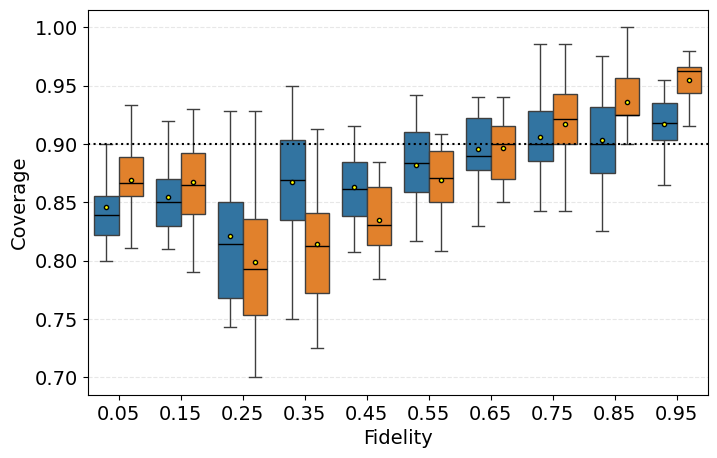

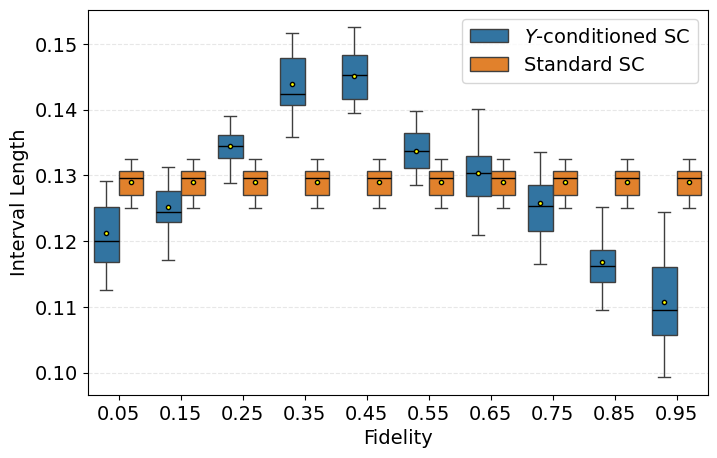

In [11]:
data = pd.read_csv("/Users/aditi/Documents/Fall_25/Quantum/UQ/main/results/conformal_NN/conditional_repeated_states/conditional_conformal_depolarize_noise_n_2.csv")
data["method"] = data["method"].replace({
    r"$Y$-cond. SC": r"$Y$-conditioned SC"})
methods_to_keep = [r"$Y$-conditioned SC", "Standard SC"]

data = data[data["method"].isin(methods_to_keep)]
plt.rcParams.update({'font.size': 14})
fig, ax = plt.subplots(figsize=(8, 5))
# ax.set_box_aspect(0.8)
sns.boxplot(data=data, x="Fidelity", y="Coverage", hue="method", showfliers=False,
                showmeans=True,
                legend=False,
                medianprops=dict(color='black'),
                meanprops=dict(marker='o', markerfacecolor='yellow', markeredgecolor='black', markersize=3))
plt.axhline(0.9, linestyle='dotted', color='black')
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.savefig("/Users/aditi/Documents/Fall_25/Quantum/UQ/main/results/figures/10_bins_conditional/conditional_conformal_depolarize_cov_n_2_1.pdf", bbox_inches='tight', dpi=300)
plt.show()   

fig, ax = plt.subplots(figsize=(8, 5))
# ax.set_box_aspect(0.8)
sns.boxplot(data=data, x="Fidelity", y="Interval Length", hue="method", showfliers=False,
                showmeans=True,
                medianprops=dict(color='black'),
                meanprops=dict(marker='o', markerfacecolor='yellow', markeredgecolor='black', markersize=3))
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.legend(loc='upper right')
plt.savefig("/Users/aditi/Documents/Fall_25/Quantum/UQ/main/results/figures/10_bins_conditional/conditional_conformal_depolarize_len_n_2_1.pdf", bbox_inches='tight', dpi=300)
plt.show()   




In [5]:
data

,Fidelity,Coverage,Interval Length,method
0,0.05,0.885906,0.115589,$Y$-cond. SC
1,0.15,0.911111,0.126481,$Y$-cond. SC
2,0.25,0.880435,0.136283,$Y$-cond. SC
3,0.35,0.885496,0.145821,$Y$-cond. SC
4,0.45,0.902174,0.148160,$Y$-cond. SC
...,...,...,...,...
595,0.55,0.913043,0.128346,Adaptive SC
596,0.65,0.945055,0.127209,Adaptive SC
597,0.75,0.920792,0.124288,Adaptive SC
598,0.85,0.942149,0.122197,Adaptive SC
